In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("../data/raw/NewsCategorizer.csv")

df.head()


,category,headline,links,short_description,keywords
0,WELLNESS,143 Miles in 35 Days: Lessons Learned,https://www.huffingtonpost.com/entry/running-l...,Resting is part of training. I've confirmed wh...,running-lessons
1,WELLNESS,Talking to Yourself: Crazy or Crazy Helpful?,https://www.huffingtonpost.com/entry/talking-t...,Think of talking to yourself as a tool to coac...,talking-to-yourself-crazy
2,WELLNESS,Crenezumab: Trial Will Gauge Whether Alzheimer...,https://www.huffingtonpost.com/entry/crenezuma...,The clock is ticking for the United States to ...,crenezumab-alzheimers-disease-drug
3,WELLNESS,"Oh, What a Difference She Made",https://www.huffingtonpost.com/entry/meaningfu...,"If you want to be busy, keep trying to be perf...",meaningful-life
4,WELLNESS,Green Superfoods,https://www.huffingtonpost.com/entry/green-sup...,"First, the bad news: Soda bread, corned beef a...",green-superfoods


In [3]:
df.shape


(50000, 5)

In [4]:
df.columns


Index(['category', 'headline', 'links', 'short_description', 'keywords'], dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   category           50000 non-null  object
 1   headline           50000 non-null  object
 2   links              50000 non-null  object
 3   short_description  50000 non-null  object
 4   keywords           47332 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


In [6]:
df.isnull().sum()


category                0
headline                0
links                   0
short_description       0
keywords             2668
dtype: int64

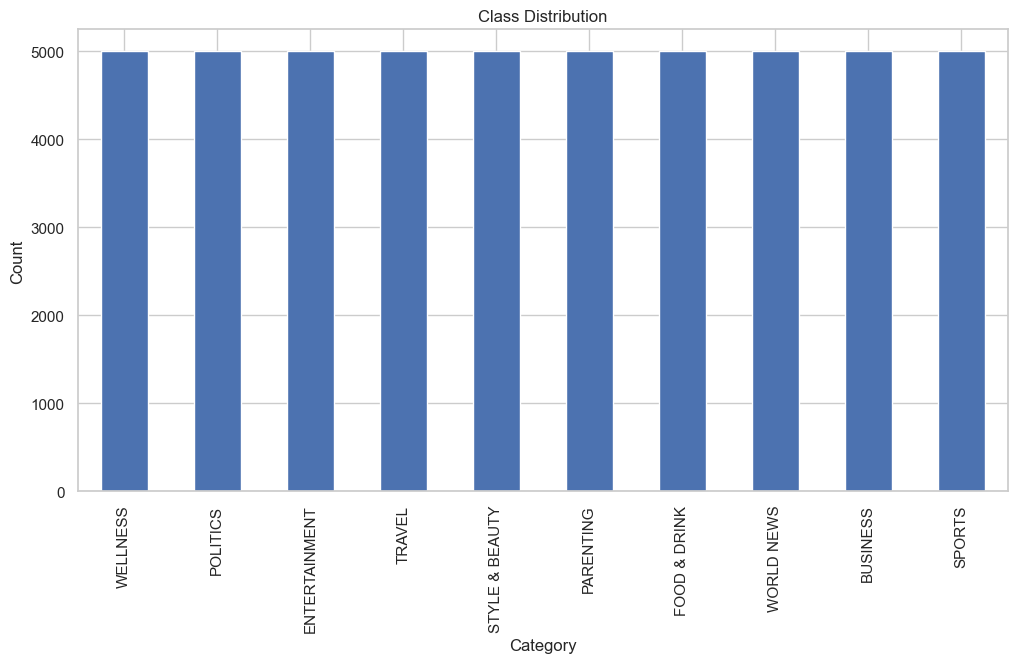

In [7]:
plt.figure(figsize=(12,6))
df['category'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()


In [8]:
df['category'].value_counts(normalize=True) * 100


category
WELLNESS          10.0
POLITICS          10.0
ENTERTAINMENT     10.0
TRAVEL            10.0
STYLE & BEAUTY    10.0
PARENTING         10.0
FOOD & DRINK      10.0
WORLD NEWS        10.0
BUSINESS          10.0
SPORTS            10.0
Name: proportion, dtype: float64

In [9]:
df['text'] = df['headline'] + " " + df['short_description']


In [10]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

df['text_length'].describe()


count    50000.000000
mean        32.334440
std         13.132873
min          4.000000
25%         24.000000
50%         30.000000
75%         38.000000
max        227.000000
Name: text_length, dtype: float64

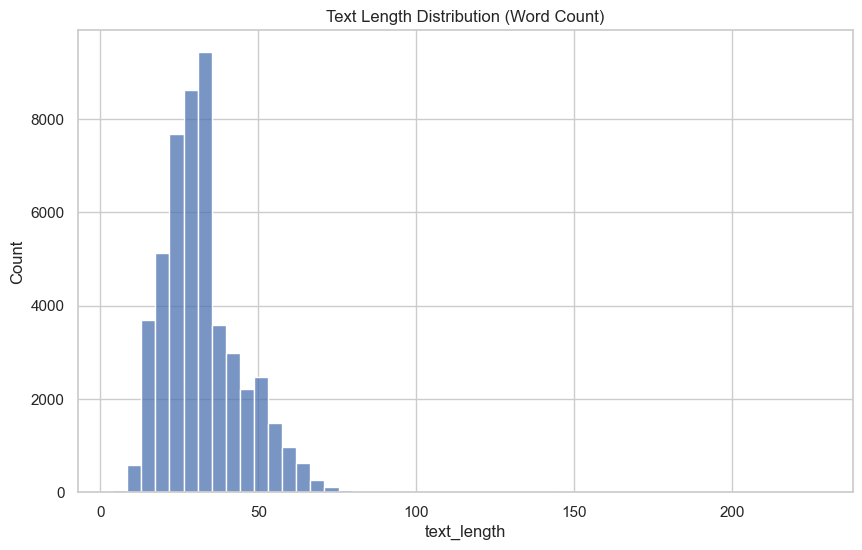

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution (Word Count)")
plt.show()


In [12]:
np.percentile(df['text_length'], [50, 75, 90, 95, 99])


array([30., 38., 51., 56., 67.])

In [13]:
for category in df['category'].unique()[:5]:
    print("\nCategory:", category)
    print(df[df['category'] == category]['text'].iloc[0])



Category: WELLNESS
143 Miles in 35 Days: Lessons Learned Resting is part of training. I've confirmed what I sort of already knew: I'm not built for running streaks. I'm built for hard workouts three to five days a week with lots of cross training, physical therapy and foam rolling. But I've also confirmed that I'm stubborn with myself.

Category: POLITICS
GOP Congressman Suggests Looser Standard Of Proof For Investigating Muslims Rep. Lee Zeldin says there needs to be "some type of process" to protect Americans, even if there isn't sufficient evidence.

Category: ENTERTAINMENT
Paul McCartney And Nirvana's Surviving Members Perform Together At Seattle Concert (VIDEO) The surviving members of Nirvana joined Paul McCartney onstage Friday night during the 71-year-old singer's Seattle concert

Category: TRAVEL
Remembering Christopher McCandless 20 Years Later Discussions of McCandless' life, either through reading the book, watching the film or hearing passing information about

Category: 

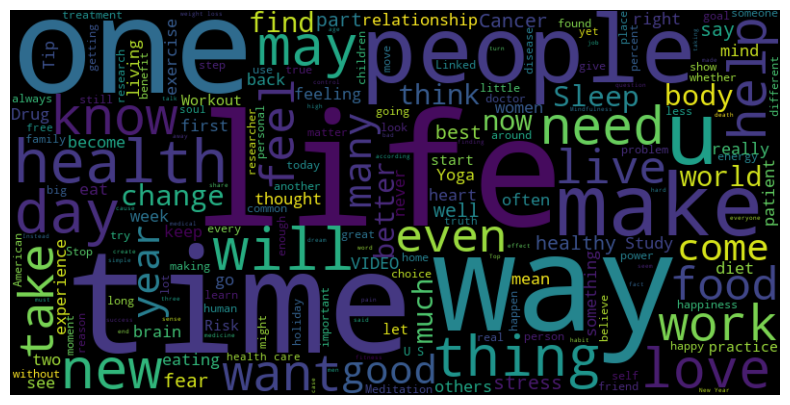

In [14]:
from wordcloud import WordCloud

text = " ".join(df[df['category'] == df['category'].unique()[0]]['text'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()
